# Preventing Data Leakage in Simulated TCSPC Data

This notebook investigates how train-test splitting strategies affect the evaluation of machine-learning models trained on simulated TCSPC decay curves.

Synthetic datasets often contain several Poisson-noisy realizations generated from the same underlying physical parameters. If these closely related curves are randomly distributed between the training and test sets, the resulting evaluation may be unrealistically optimistic.

The notebook compares:

* an ordinary random row-level split;
* a group-aware split based on simulation parameter sets;
* a lifetime-interval holdout experiment;
* a noise-robustness experiment.

The purpose is to distinguish performance on familiar parameter regions from robustness to genuinely unfamiliar physical or statistical conditions.

## 1. Scientific motivation

A supervised machine-learning model is normally trained on one subset of a dataset and evaluated on another subset that was not used during training.

For the evaluation to be scientifically meaningful, the test samples should represent genuinely unseen information.

In simulated TCSPC datasets, however, multiple measured curves may be generated from the same expected decay curve. For example, several Poisson-noisy realizations may share exactly the same:

* fluorescence lifetime;
* decay amplitude;
* background level;
* time axis;
* decay model.

Only the random Poisson realization differs between these curves.

Consider three simulated curves generated using the same physical parameters:

- lifetime: 2.5 ns
- amplitude: 10,000 counts
- background: 5 counts per bin

The corresponding measured curves may differ because independent Poisson noise is applied:

| Curve | Parameter set | Random seed |
|---:|---|---:|
| 1 | A | 101 |
| 2 | A | 102 |
| 3 | A | 103 |

An ordinary random train-test split may assign curves 1 and 2 to the training set and curve 3 to the test set.

Although curve 3 was not directly used during training, it originates from the same expected decay curve as curves 1 and 2.

The model is therefore tested on a sample that is statistically new but physically almost identical to samples already present in the training set.

This problem is not classical target leakage because the true lifetime is not directly included among the model input features.

Instead, it is a form of **simulation-group leakage** or **dependence between training and test samples**.

The training and test sets are not sufficiently independent because they contain different noisy realizations of the same underlying simulation parameter set.

A model evaluated under these conditions may achieve a very small test error without demonstrating that it can generalize to:

* unseen lifetime values;
* unseen combinations of lifetime, amplitude, and background;
* lower photon-count conditions;
* stronger background noise;
* different decay models;
* unfamiliar instrument-response functions.

It is therefore important to define what kind of generalization each evaluation experiment is intended to measure.

In this notebook, four generalization concepts are distinguished.

### Interpolation performance

The test data lie within the physical parameter ranges represented during training, but the exact simulation parameter combinations are new.

### Robustness to new noise levels

The physical decay model remains unchanged, but the test curves contain photon counts or background levels not represented during training.

### Robustness to model mismatch

The test curves do not exactly follow the decay model used to generate the training data. For example, a model trained on mono-exponential curves may later be tested on bi-exponential curves.

### Robustness to unfamiliar IRFs

After instrument-response-function convolution is added to the toolkit, a model may be trained using one family of IRFs and evaluated using different IRF
shapes or widths.

The main question throughout this notebook is:

> What exactly is unfamiliar to the model in the test set?

A test set may differ from the training set only through a new Poisson realization, or it may introduce a genuinely new physical or statistical
condition.

These situations support different scientific claims and should therefore be evaluated separately.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)

from tcspc_toolkit.models import monoexponential_decay
from tcspc_toolkit.simulation import sample_photon_counts

## 2. Generation of repeated noise realizations

To demonstrate the difference between row-level and group-aware splitting, this
notebook requires a dataset containing several measured curves for each
underlying physical parameter combination.

For one parameter group, the lifetime, amplitude, background, time axis, and
expected decay curve remain fixed. Multiple measured curves are then generated
by applying independent Poisson sampling to that same expected curve.

The resulting hierarchy is:

```text
simulation parameter group
├── Poisson realization 1
├── Poisson realization 2
├── Poisson realization 3
└── ...
```

Curves belonging to one group are not numerically identical because every Poisson realization is independently sampled. Nevertheless, they share the same underlying expected decay and are therefore more closely related than curves generated from different physical parameter combinations.

### Why we need both identifiers

We will eventually have metadata similar to:

| `curve_id` | `parameter_group` | `realization_id` | `lifetime_ns` |
|---:|---:|---:|---:|
| 0 | 0 | 0 | 1.25 |
| 1 | 0 | 1 | 1.25 |
| 2 | 0 | 2 | 1.25 |
| 3 | 1 | 0 | 2.50 |

Three identifiers will be retained

- `curve_id` uniquely identifies every measured histogram;
- `parameter_group` identifies the shared expected decay;
- `realization_id` identifies the Poisson draw inside that group.

The `parameter_group` variable will later be used to ensure that all realizations of one expected decay are assigned either to the training set or to the test set, but never to both.

In [2]:
n_time_bins = 256
start_time_ns = 0.0
end_time_ns = 12.0

time_ns = np.linspace(
    start_time_ns,
    end_time_ns,
    n_time_bins,
    dtype=np.float64,
)

n_parameter_groups = 500
n_realizations_per_group = 5

lifetime_range_ns = (0.5, 5.0)
amplitude_range = (500.0, 10_000.0)
background_range = (0.0, 10.0)

random_seed = 42
rng = np.random.default_rng(random_seed)

In [3]:
n_curves = n_parameter_groups * n_realizations_per_group

print(f"Number of parameter groups: {n_parameter_groups}")
print(f"Realizations per group: {n_realizations_per_group}")
print(f"Total number of curves: {n_curves}")
print(f"Number of time bins: {n_time_bins}")
print(f"Input-matrix shape: ({n_curves}, {n_time_bins})")

Number of parameter groups: 500
Realizations per group: 5
Total number of curves: 2500
Number of time bins: 256
Input-matrix shape: (2500, 256)


### Sample parameter groups

In [4]:
group_lifetimes_ns = rng.uniform(
    low=lifetime_range_ns[0],
    high=lifetime_range_ns[1],
    size=n_parameter_groups,
)

group_amplitudes = rng.uniform(
    low=amplitude_range[0],
    high=amplitude_range[1],
    size=n_parameter_groups,
)

group_backgrounds = rng.uniform(
    low=background_range[0],
    high=background_range[1],
    size=n_parameter_groups,
)

In [5]:
parameter_table = pd.DataFrame(
    {
        "parameter_group": np.arange(
            n_parameter_groups,
            dtype=np.int64,
        ),
        "lifetime_ns": group_lifetimes_ns,
        "amplitude": group_amplitudes,
        "background": group_backgrounds,
    }
)

parameter_table.head()

,parameter_group,lifetime_ns,amplitude,background
0,0,3.982802,7498.704041,0.620631
1,1,2.474953,8920.827424,4.582620
2,2,4.363691,9250.043374,1.290301
3,3,3.638156,5284.512789,1.523267
4,4,0.923798,5442.613590,6.322828


In [6]:
parameter_table.describe()

,parameter_group,lifetime_ns,amplitude,background
count,500.000000,500.000000,500.000000,500.000000
mean,249.500000,2.730566,5237.406222,5.045747
std,144.481833,1.290476,2817.704575,2.915219
min,0.000000,0.524434,511.714094,0.005187
25%,124.750000,1.561917,2811.523587,2.460615
50%,249.500000,2.754018,5190.300206,4.924648
75%,374.250000,3.862599,7752.092448,7.590803
max,499.000000,4.995971,9988.062016,9.994219


In [7]:
assert np.all(group_lifetimes_ns >= lifetime_range_ns[0])
assert np.all(group_lifetimes_ns < lifetime_range_ns[1])

assert np.all(group_amplitudes >= amplitude_range[0])
assert np.all(group_amplitudes < amplitude_range[1])

assert np.all(group_backgrounds >= background_range[0])
assert np.all(group_backgrounds < background_range[1])

In [8]:
measured_curves = np.empty(
    shape=(n_curves, n_time_bins),
    dtype=np.int64,
)

expected_curves = np.empty(
    shape=(n_parameter_groups, n_time_bins),
    dtype=np.float64,
)

In [9]:
curve_ids = np.arange(n_curves, dtype=np.int64)

parameter_groups = np.empty(
    n_curves,
    dtype=np.int64,
)

realization_ids = np.empty(
    n_curves,
    dtype=np.int64,
)

curve_lifetimes_ns = np.empty(
    n_curves,
    dtype=np.float64,
)

curve_amplitudes = np.empty(
    n_curves,
    dtype=np.float64,
)

curve_backgrounds = np.empty(
    n_curves,
    dtype=np.float64,
)

### Generate the grouped curves

In [10]:
curve_id = 0

for parameter_group in range(n_parameter_groups):
    lifetime_ns = group_lifetimes_ns[parameter_group]
    amplitude = group_amplitudes[parameter_group]
    background = group_backgrounds[parameter_group]

    expected_counts = monoexponential_decay(
        time=time_ns,
        amplitude=amplitude,
        lifetime=lifetime_ns,
        background=background,
    )

    expected_curves[parameter_group] = expected_counts

    for realization_id in range(n_realizations_per_group):
        measured_counts = sample_photon_counts(
            expected_counts=expected_counts,
            rng=rng,
        )

        measured_curves[curve_id] = measured_counts
        parameter_groups[curve_id] = parameter_group
        realization_ids[curve_id] = realization_id
        curve_lifetimes_ns[curve_id] = lifetime_ns
        curve_amplitudes[curve_id] = amplitude
        curve_backgrounds[curve_id] = background

        curve_id += 1

In [11]:
assert curve_id == n_curves
assert measured_curves.shape == (n_curves, n_time_bins)
assert expected_curves.shape == (
    n_parameter_groups,
    n_time_bins,
)

In [12]:
curve_metadata = pd.DataFrame(
    {
        "curve_id": curve_ids,
        "parameter_group": parameter_groups,
        "realization_id": realization_ids,
        "lifetime_ns": curve_lifetimes_ns,
        "amplitude": curve_amplitudes,
        "background": curve_backgrounds,
        "measured_total_counts": measured_curves.sum(axis=1),
    }
)

curve_metadata.head(10)

,curve_id,parameter_group,realization_id,lifetime_ns,amplitude,background,measured_total_counts
0,0,0,0,3.982802,7498.704041,0.620631,608338
1,1,0,1,3.982802,7498.704041,0.620631,607223
2,2,0,2,3.982802,7498.704041,0.620631,606840
3,3,0,3,3.982802,7498.704041,0.620631,608589
4,4,0,4,3.982802,7498.704041,0.620631,607563
5,5,1,0,2.474953,8920.827424,4.582620,470429
6,6,1,1,2.474953,8920.827424,4.582620,470395
7,7,1,2,2.474953,8920.827424,4.582620,470939
8,8,1,3,2.474953,8920.827424,4.582620,471519
9,9,1,4,2.474953,8920.827424,4.582620,470882


In [14]:
group_sizes = curve_metadata.groupby(
    "parameter_group"
).size()

assert group_sizes.nunique() == 1
assert group_sizes.iloc[0] == n_realizations_per_group

In [16]:
within_group_parameter_counts = (
    curve_metadata.groupby("parameter_group")[
        ["lifetime_ns", "amplitude", "background"]
    ]
    .nunique()
)

assert np.all(
    within_group_parameter_counts.to_numpy() == 1
)

In [18]:
first_group_indices = np.flatnonzero(
    parameter_groups == 0
)

first_group_curves = measured_curves[
    first_group_indices
]

n_unique_curves_in_first_group = np.unique(
    first_group_curves,
    axis=0,
).shape[0]

print(
    "Unique measured curves in the first group:",
    n_unique_curves_in_first_group,
)

Unique measured curves in the first group: 5


### Visual comparison of repeated realizations

The curves below belong to one simulation parameter group. They therefore share the same lifetime, amplitude, background, and expected decay. Their visible differences arise only from independent Poisson sampling.

This illustrates why the curves are neither exact duplicates nor fully independent physical cases.


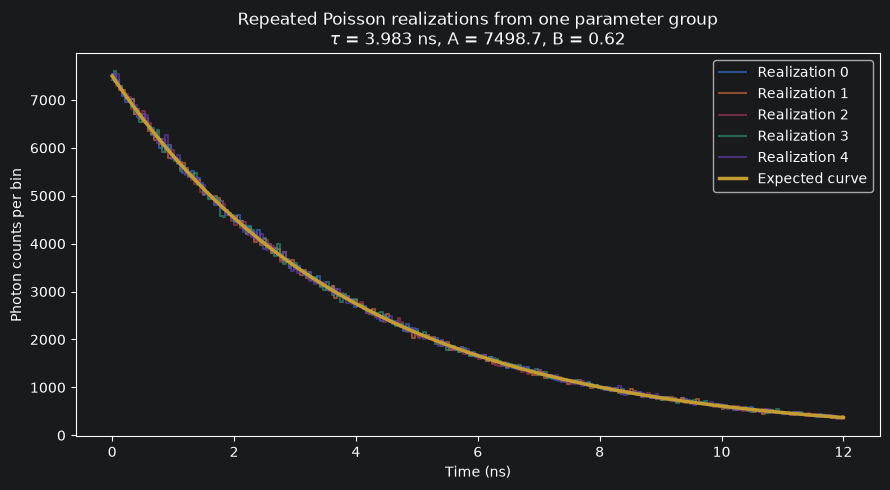

In [19]:
selected_group = 0

selected_indices = np.flatnonzero(
    parameter_groups == selected_group
)

selected_lifetime = group_lifetimes_ns[selected_group]
selected_amplitude = group_amplitudes[selected_group]
selected_background = group_backgrounds[selected_group]

plt.figure(figsize=(9, 5))

for index in selected_indices:
    realization_id = realization_ids[index]

    plt.step(
        time_ns,
        measured_curves[index],
        where="mid",
        alpha=0.65,
        label=f"Realization {realization_id}",
    )

plt.plot(
    time_ns,
    expected_curves[selected_group],
    linewidth=2.5,
    label="Expected curve",
)

plt.xlabel("Time (ns)")
plt.ylabel("Photon counts per bin")
plt.title(
    "Repeated Poisson realizations from one parameter group\n"
    f"$\\tau$ = {selected_lifetime:.3f} ns, "
    f"A = {selected_amplitude:.1f}, "
    f"B = {selected_background:.2f}"
)
plt.legend()
plt.tight_layout()
plt.show()

### Preparation of model inputs

As in the first machine-learning baseline, each measured histogram is normalized by its total photon count:

$$
x_{i,j}^{\mathrm{norm}}
=
\frac{x_{i,j}}{\sum_k x_{i,k}},
$$

where \(i\) indexes the decay curve, \(j\) indexes the time bin, and the sum runs over all time bins \(k\) of curve \(i\).

This removes the overall count scale and makes the initial model input primarily represent the temporal shape of each decay. The unnormalized total photon count is retained separately in the metadata for later noise-dependent evaluation.

Because each curve is normalized using only its own measured counts, this operation does not estimate parameters from the complete dataset and therefore does not transfer population-level information between training and test sets.


In [20]:
curve_totals = measured_curves.sum(
    axis=1,
    keepdims=True,
)

if np.any(curve_totals == 0):
    raise ValueError(
        "At least one simulated curve contains zero total counts."
    )

X = (
    measured_curves.astype(np.float64)
    / curve_totals
)

y = curve_lifetimes_ns.copy()
groups = parameter_groups.copy()

In [22]:
row_sums = X.sum(axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("groups shape:", groups.shape)
print("Minimum normalized row sum:", row_sums.min())
print("Maximum normalized row sum:", row_sums.max())

assert np.allclose(row_sums, 1.0)

X shape: (2500, 256)
y shape: (2500,)
groups shape: (2500,)
Minimum normalized row sum: 0.9999999999999996
Maximum normalized row sum: 1.0000000000000004
